In [ ]:
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
from datasets import load_dataset
import matplotlib.pyplot as plt

from diffusers import (
    AutoencoderKL,
    UNet2DConditionModel,
    DDPMScheduler,
)
from transformers import CLIPTextModel, CLIPTokenizer
from peft import LoraConfig, get_peft_model

# 1. Load the Hugging Face Dataset

In [ ]:
dataset = load_dataset("kanbaa/InteriorDesigns")
hf_dataset = dataset["train"]

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/317 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/390M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [ ]:
class InteriorDesignDataset(Dataset):
    def __init__(self, hf_dataset, image_size=512):
        self.dataset = hf_dataset
        self.image_size = image_size
        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.Lambda(lambda image: image.convert("RGB")),  # Force RGB conversion
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
        ])

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        sample = self.dataset[idx]
        image = sample["image"]
        if not isinstance(image, Image.Image):
            image = Image.open(image).convert("RGB")  # Ensure RGB if loading from file
        image = self.transform(image)
        room_type = sample.get("room_type", "")
        description = sample.get("text", "")
        caption = f"{room_type}. {description}"
        return {"pixel_values": image, "caption": caption}

In [ ]:
train_dataset = InteriorDesignDataset(hf_dataset, image_size=512)
dataloader = DataLoader(train_dataset, batch_size=1, shuffle=True)

In [ ]:
# ==============================================
# 3. Load Model Components for Fine-Tuning
# ==============================================
model_id = "runwayml/stable-diffusion-v1-5"

tokenizer = CLIPTokenizer.from_pretrained(model_id, subfolder="tokenizer")
text_encoder = CLIPTextModel.from_pretrained(model_id, subfolder="text_encoder")
vae = AutoencoderKL.from_pretrained(model_id, subfolder="vae")
unet = UNet2DConditionModel.from_pretrained(model_id, subfolder="unet")
scheduler = DDPMScheduler.from_pretrained(model_id, subfolder="scheduler")

tokenizer_config.json:   0%|          | 0.00/806 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.06M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/617 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

scheduler_config.json:   0%|          | 0.00/308 [00:00<?, ?B/s]

In [ ]:
lora_config = LoraConfig(
    r=4,
    lora_alpha=32,
    target_modules=["query", "key", "value", "proj_out"],  # Corrected layer names
    lora_dropout=0.1,
    bias="none"
)

unet = get_peft_model(unet, lora_config)
unet.print_trainable_parameters()

trainable params: 99,840 || all params: 859,620,804 || trainable%: 0.0116


/usr/local/lib/python3.11/dist-packages/peft/mapping_func.py:73: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/peft/tuners/tuners_utils.py:167: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
unet.to(device)
text_encoder.to(device)
vae.to(device)

optimizer = torch.optim.AdamW(unet.parameters(), lr=1e-4)
num_epochs = 8

In [ ]:
scaler = torch.cuda.amp.GradScaler()  # For mixed precision
accumulation_steps = 4  # Number of steps before optimizer step

<ipython-input-17-17c7574a4c2a>:1: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()  # For mixed precision


In [ ]:
loss_values = []

In [ ]:
for epoch in range(num_epochs):
    for step, batch in enumerate(dataloader):
        optimizer.zero_grad()
        images = batch["pixel_values"].to(device)
        captions = batch["caption"]

        inputs = tokenizer(captions, padding="max_length", max_length=77, truncation=True, return_tensors="pt")
        input_ids = inputs.input_ids.to(device)
        text_embeddings = text_encoder(input_ids)[0]

        with torch.no_grad():
            latents = vae.encode(images).latent_dist.sample() * 0.18215

        noise = torch.randn_like(latents)
        timesteps = torch.randint(0, scheduler.num_train_timesteps, (latents.shape[0],), device=device).long()
        noisy_latents = scheduler.add_noise(latents, noise, timesteps)

        noise_pred = unet(noisy_latents, timesteps, encoder_hidden_states=text_embeddings).sample
        loss = torch.nn.functional.mse_loss(noise_pred, noise)
        loss.backward()
        optimizer.step()

        loss_values.append(loss.item())  # Store loss for plotting

        if step % 10 == 0:
            print(f"Epoch {epoch+1}, Step {step}: Loss = {loss.item():.4f}")

Epoch 1, Step 0: Loss = 0.5209
Epoch 1, Step 10: Loss = 0.0494
Epoch 1, Step 20: Loss = 0.1076
Epoch 1, Step 30: Loss = 0.2207
Epoch 1, Step 40: Loss = 0.1549
Epoch 1, Step 50: Loss = 0.0167
Epoch 1, Step 60: Loss = 0.0393
Epoch 1, Step 70: Loss = 0.0129
Epoch 1, Step 80: Loss = 0.1153
Epoch 1, Step 90: Loss = 0.0260
Epoch 1, Step 100: Loss = 0.0839
Epoch 1, Step 110: Loss = 0.0022
Epoch 1, Step 120: Loss = 0.1535
Epoch 1, Step 130: Loss = 0.1125
Epoch 1, Step 140: Loss = 0.0194
Epoch 1, Step 150: Loss = 0.0038
Epoch 1, Step 160: Loss = 0.1089
Epoch 1, Step 170: Loss = 0.0101
Epoch 1, Step 180: Loss = 0.0104
Epoch 1, Step 190: Loss = 0.1184
Epoch 1, Step 200: Loss = 0.0059
Epoch 1, Step 210: Loss = 0.1471
Epoch 1, Step 220: Loss = 0.0029
Epoch 1, Step 230: Loss = 0.0751
Epoch 1, Step 240: Loss = 0.0615
Epoch 1, Step 250: Loss = 0.0028
Epoch 1, Step 260: Loss = 0.0567
Epoch 1, Step 270: Loss = 0.2614
Epoch 1, Step 280: Loss = 0.0275
Epoch 1, Step 290: Loss = 0.4000
Epoch 1, Step 300: Lo

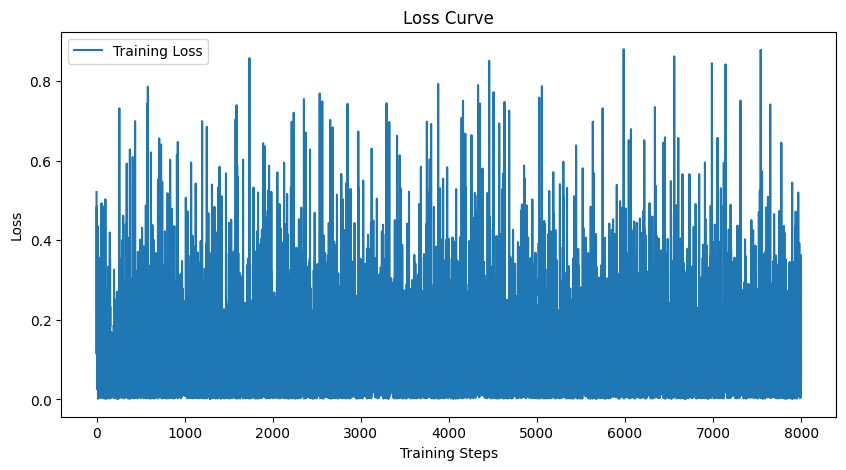

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(loss_values, label="Training Loss")
plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.show()

In [ ]:
def show_images(original, noisy, denoised):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    def tensor_to_image(tensor):
        tensor = tensor.squeeze(0).permute(1, 2, 0).cpu().numpy()
        return (tensor * 0.5 + 0.5).clip(0, 1)  # Unnormalize

    axes[0].imshow(tensor_to_image(original))
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    axes[1].imshow(tensor_to_image(noisy))
    axes[1].set_title("Noisy Image")
    axes[1].axis("off")

    axes[2].imshow(tensor_to_image(denoised))
    axes[2].set_title("Denoised Image")
    axes[2].axis("off")

    plt.show()

In [ ]:
# Get a batch of images
batch = next(iter(dataloader))
images = batch["pixel_values"].to(device)

In [ ]:
# Encode and add noise
with torch.no_grad():
    latents = vae.encode(images).latent_dist.sample() * 0.18215
noise = torch.randn_like(latents)
timesteps = torch.randint(0, scheduler.num_train_timesteps, (latents.shape[0],), device=device).long()
noisy_latents = scheduler.add_noise(latents, noise, timesteps)

In [ ]:
# Denoise
denoised_latents = unet(noisy_latents, timesteps, encoder_hidden_states=text_encoder(input_ids.to(device))[0]).sample

In [ ]:
# Decode latents back to images
with torch.no_grad():
    original_images = vae.decode(latents / 0.18215).sample
    noisy_images = vae.decode(noisy_latents / 0.18215).sample
    denoised_images = vae.decode(denoised_latents / 0.18215).sample

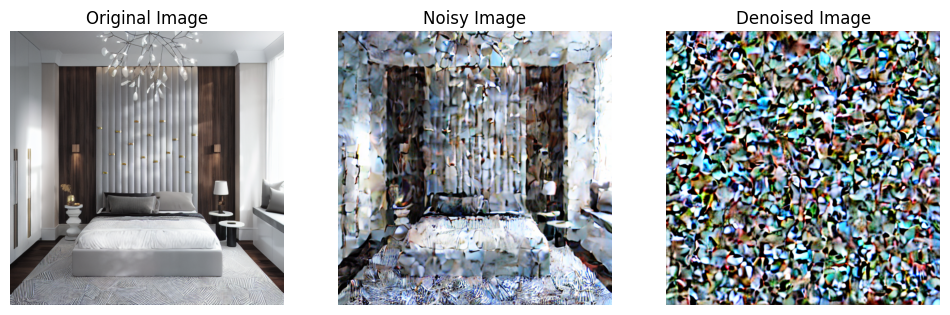

In [ ]:
# Show the comparison
show_images(original_images, noisy_images, denoised_images)

In [ ]:
save_path = "/content/lora-adapters"
unet.save_pretrained(save_path)

In [ ]:
from diffusers import StableDiffusionPipeline
from peft import PeftModel

# Define paths
base_model_id = "runwayml/stable-diffusion-v1-5"
fine_tuned_lora_path = "/content/lora-adapters"

# Load base Stable Diffusion pipeline
pipeline = StableDiffusionPipeline.from_pretrained(base_model_id)

# Load fine-tuned LoRA adapters
pipeline.unet = PeftModel.from_pretrained(pipeline.unet, fine_tuned_lora_path)

# Move to GPU if available
device = "cuda" if torch.cuda.is_available() else "cpu"
pipeline.to(device)


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/342 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.72k [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/peft/peft_model.py:569: UserWarning: Found missing adapter keys while loading the checkpoint: ['base_model.model.down_blocks.0.attentions.0.proj_out.lora_A.default.weight', 'base_model.model.down_blocks.0.attentions.0.proj_out.lora_B.default.weight', 'base_model.model.down_blocks.0.attentions.1.proj_out.lora_A.default.weight', 'base_model.model.down_blocks.0.attentions.1.proj_out.lora_B.default.weight', 'base_model.model.down_blocks.1.attentions.0.proj_out.lora_A.default.weight', 'base_model.model.down_blocks.1.attentions.0.proj_out.lora_B.default.weight', 'base_model.model.down_blocks.1.attentions.1.proj_out.lora_A.default.weight', 'base_model.model.down_blocks.1.attentions.1.proj_out.lora_B.default.weight', 'base_model.model.down_blocks.2.attentions.0.proj_out.lora_A.default.weight', 'base_model.model.down_blocks.2.attentions.0.proj_out.lora_B.default.weight', 'base_model.model.down_blocks.2.attentions.1.proj_out.lora_A.default.weight', 'base_m

StableDiffusionPipeline {
  "_class_name": "StableDiffusionPipeline",
  "_diffusers_version": "0.33.1",
  "_name_or_path": "runwayml/stable-diffusion-v1-5",
  "feature_extractor": [
    "transformers",
    "CLIPImageProcessor"
  ],
  "image_encoder": [
    null,
    null
  ],
  "requires_safety_checker": true,
  "safety_checker": [
    "stable_diffusion",
    "StableDiffusionSafetyChecker"
  ],
  "scheduler": [
    "diffusers",
    "PNDMScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

In [ ]:
prompt = "a living room with a large black sofa and a round black coffee table"

# Generate image
image = pipeline(prompt).images[0]

# Save or display the image
image.save("generated_image.png")
image.show()


  0%|          | 0/50 [00:00<?, ?it/s]

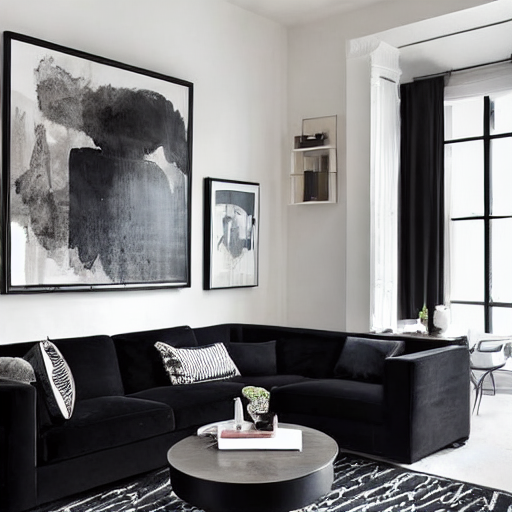

In [ ]:
from IPython.display import display
display(image)

In [ ]:
prompt = "a minimalist living room with white walls, light wood flooring, and a gray sofa"

# Generate image
image = pipeline(prompt).images[0]

# Save or display the image
image.show()

  0%|          | 0/50 [00:00<?, ?it/s]

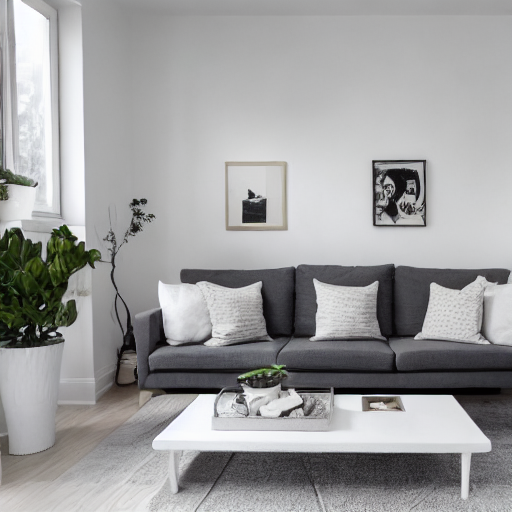

In [ ]:
from IPython.display import display
display(image)

  0%|          | 0/50 [00:00<?, ?it/s]

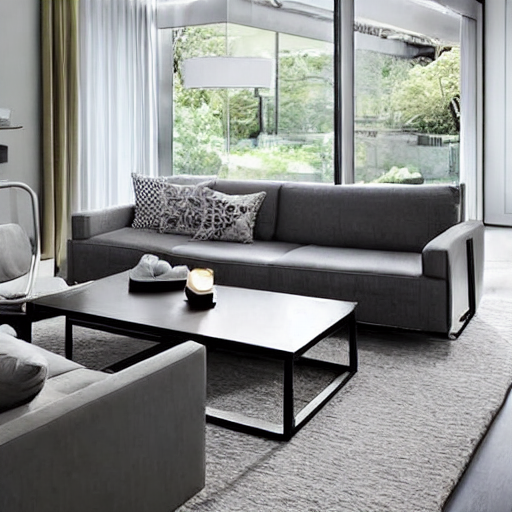

In [ ]:
prompt = "A  modern living room with gray sofa and steel table in center "

# Generate image
image = pipeline(prompt).images[0]
# Save or display the image
image.show()
display(image)

  0%|          | 0/50 [00:00<?, ?it/s]

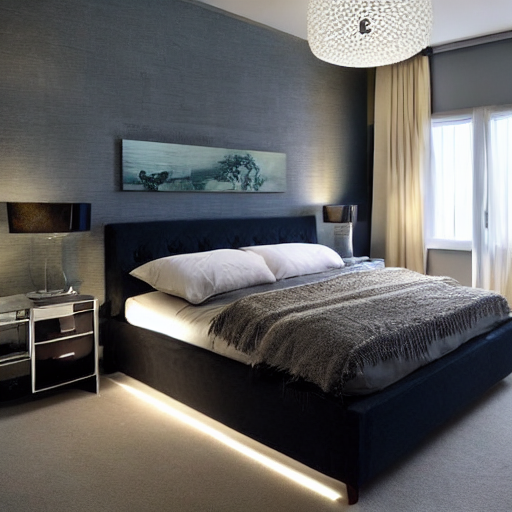

In [ ]:
prompt = "A modern bedroom "

# Generate image
image = pipeline(prompt).images[0]
# Save or display the image
image.show()
display(image)